# 🏏 ODI Cricket Analytics — Exploratory Data Analysis
---

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded!')

Libraries loaded!


## Step 2 — Load Data

In [2]:
# Load both CSVs — rakhna same folder mein
match_data = pd.read_csv(r'D:\My Files\02_Academic\Data Science\Projects\10_Real_World_Projects\02_Cricket_Analytics\Data/ODI_Match_Data.csv')
match_info = pd.read_csv(r'D:\My Files\02_Academic\Data Science\Projects\10_Real_World_Projects\02_Cricket_Analytics\Data/ODI_Match_info.csv')

print(f'Ball-by-ball rows : {len(match_data):,}')
print(f'Match info rows   : {len(match_info):,}')

Ball-by-ball rows : 1,265,103
Match info rows   : 2,379


## Step 3 — Basic EDA

In [3]:
print('=== MATCH INFO — First 5 rows ===')
match_info.head()

=== MATCH INFO — First 5 rows ===


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1389389,2023/24,Indore,2023/09/24,India,Australia,Australia,field,D/L,1,India,99,0,SS Iyer,"Holkar Cricket Stadium, Indore",J Madanagopal,HDPK Dharmasena,KN Ananthapadmanabhan
1,1336129,2023,Nottingham,2023/09/23,England,Ireland,Ireland,field,normal,0,England,48,0,WG Jacks,"Trent Bridge, Nottingham",DJ Millns,RJ Tucker,PR Reiffel
2,1395701,2023,Dhaka,2023/09/23,New Zealand,Bangladesh,New Zealand,bat,normal,0,New Zealand,86,0,IS Sodhi,"Shere Bangla National Stadium, Mirpur",M Erasmus,Sharfuddoula,Nitin Menon
3,1389388,2023/24,Chandigarh,2023/09/22,Australia,India,India,field,normal,0,India,0,5,Mohammed Shami,"Punjab Cricket Association IS Bindra Stadium, ...",KN Ananthapadmanabhan,HDPK Dharmasena,J Madanagopal
4,1395700,2023,Dhaka,2023/09/21,New Zealand,Bangladesh,Bangladesh,field,normal,0,NaN,0,0,NaN,"Shere Bangla National Stadium, Mirpur",Nitin Menon,Sharfuddoula,M Erasmus


In [4]:
print('=== MATCH DATA — First 5 rows ===')
match_data.head()

=== MATCH DATA — First 5 rows ===


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,cricsheet_id
0,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.1,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
1,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.2,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
2,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.3,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
3,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.4,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
4,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.5,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389


In [5]:
print('\n--- match_info.info() ---')
match_info.info()


--- match_info.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2379 entries, 0 to 2378
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               2379 non-null   int64 
 1   season           2379 non-null   object
 2   city             2069 non-null   object
 3   date             2379 non-null   object
 4   team1            2379 non-null   object
 5   team2            2379 non-null   object
 6   toss_winner      2379 non-null   object
 7   toss_decision    2379 non-null   object
 8   result           2379 non-null   object
 9   dl_applied       2379 non-null   int64 
 10  winner           2259 non-null   object
 11  win_by_runs      2379 non-null   int64 
 12  win_by_wickets   2379 non-null   int64 
 13  player_of_match  2228 non-null   object
 14  venue            2379 non-null   object
 15  umpire1          2379 non-null   object
 16  umpire2          2379 non-null   object
 17  umpire

In [6]:
print('\n--- match_data.info() ---')
match_data.info()


--- match_data.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1265103 entries, 0 to 1265102
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   match_id                1265103 non-null  int64  
 1   season                  1265103 non-null  object 
 2   start_date              1265103 non-null  object 
 3   venue                   1265103 non-null  object 
 4   innings                 1265103 non-null  int64  
 5   ball                    1265103 non-null  float64
 6   batting_team            1265103 non-null  object 
 7   bowling_team            1265103 non-null  object 
 8   striker                 1265103 non-null  object 
 9   non_striker             1265103 non-null  object 
 10  bowler                  1265103 non-null  object 
 11  runs_off_bat            1265103 non-null  int64  
 12  extras                  1265103 non-null  int64  
 13  wides                   28990 

In [7]:
print('=== Missing Values — match_info ===')
print(match_info.isnull().sum())
print('\n=== Missing Values — match_data ===')
print(match_data.isnull().sum())

=== Missing Values — match_info ===
id                   0
season               0
city               310
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner             120
win_by_runs          0
win_by_wickets       0
player_of_match    151
venue                0
umpire1              0
umpire2              0
umpire3            282
dtype: int64

=== Missing Values — match_data ===
match_id                        0
season                          0
start_date                      0
venue                           0
innings                         0
ball                            0
batting_team                    0
bowling_team                    0
striker                         0
non_striker                     0
bowler                          0
runs_off_bat                    0
extras                          0
wides                     1236113
noballs                 

In [8]:
match_info.describe(include='all')

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
count,2.379000e+03,2379,2069,2379,2379,2379,2379,2379,2379,2379.000000,2259,2379.000000,2379.000000,2228,2379,2379,2379,2097
unique,NaN,43,145,2013,26,27,27,2,2,NaN,27,NaN,NaN,642,293,147,153,151
top,NaN,2006/07,Mirpur,2007/02/04,Australia,Sri Lanka,India,bat,normal,NaN,India,NaN,NaN,V Kohli,Harare Sports Club,Aleem Dar,SJA Taufel,NJ Llong
freq,NaN,131,89,4,254,266,243,1218,2178,NaN,290,NaN,NaN,39,113,185,111,76
mean,7.114354e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.084489,NaN,34.680538,2.750736,NaN,NaN,NaN,NaN,NaN
std,4.287345e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.278179,NaN,53.989592,3.238695,NaN,NaN,NaN,NaN,NaN
min,6.481400e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,3.353495e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,6.490950e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,1.144488e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,58.000000,6.000000,NaN,NaN,NaN,NaN,NaN


## Step 4 — Data Cleaning

In [9]:
# Standardize column names
match_info.columns = match_info.columns.str.strip().str.lower().str.replace(' ', '_')
match_data.columns = match_data.columns.str.strip().str.lower().str.replace(' ', '_')

# Parse date
match_info['date'] = pd.to_datetime(match_info['date'], errors='coerce')
match_info['year'] = match_info['date'].dt.year
match_info['month'] = match_info['date'].dt.month

# Numeric fix
for col in ['runs_batter', 'runs_extras', 'runs_total']:
    if col in match_data.columns:
        match_data[col] = pd.to_numeric(match_data[col], errors='coerce').fillna(0)

# Drop duplicates
match_info.drop_duplicates(inplace=True)
match_data.drop_duplicates(inplace=True)

print('Cleaning done!')
print(f'match_info shape: {match_info.shape}')
print(f'match_data shape: {match_data.shape}')

Cleaning done!
match_info shape: (2379, 20)
match_data shape: (1265088, 23)


## Step 5 — Team Analytics

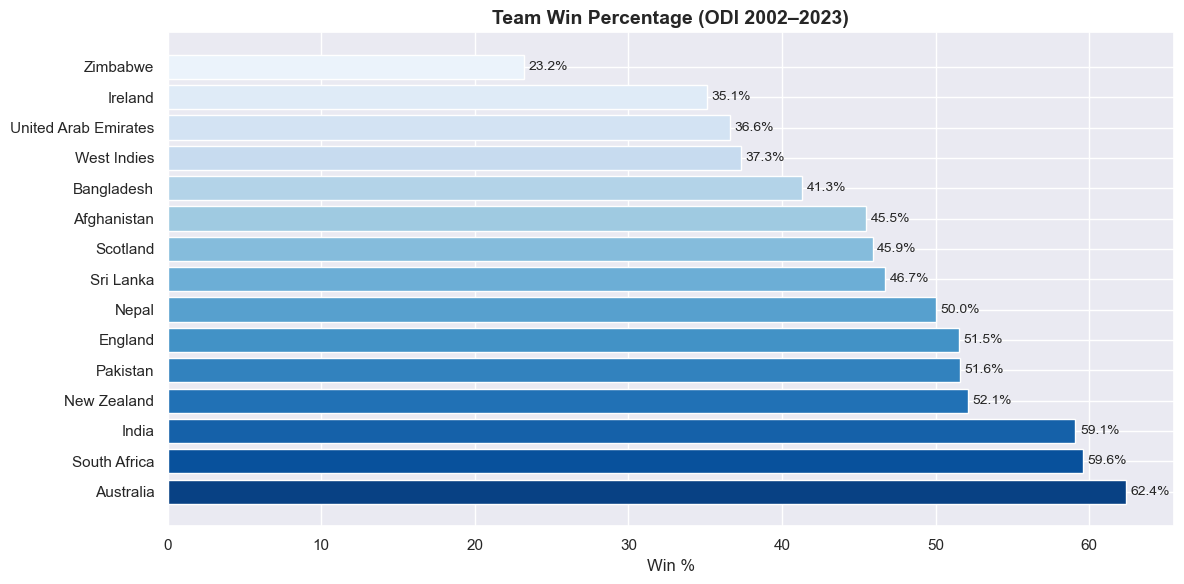

In [10]:
# --- Win % per team ---
wins = match_info['winner'].value_counts().head(15).reset_index()
wins.columns = ['Team', 'Wins']

total_played = {}
for t in wins['Team']:
    played = ((match_info['team1'] == t) | (match_info['team2'] == t)).sum()
    total_played[t] = played

wins['Played'] = wins['Team'].map(total_played)
wins['Win%']   = (wins['Wins'] / wins['Played'] * 100).round(1)
wins_sorted = wins.sort_values('Win%', ascending=False)

plt.figure(figsize=(12,6))
bars = plt.barh(wins_sorted['Team'], wins_sorted['Win%'],
                color=sns.color_palette('Blues_r', len(wins_sorted)))
plt.xlabel('Win %')
plt.title('Team Win Percentage (ODI 2002–2023)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, wins_sorted['Win%']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

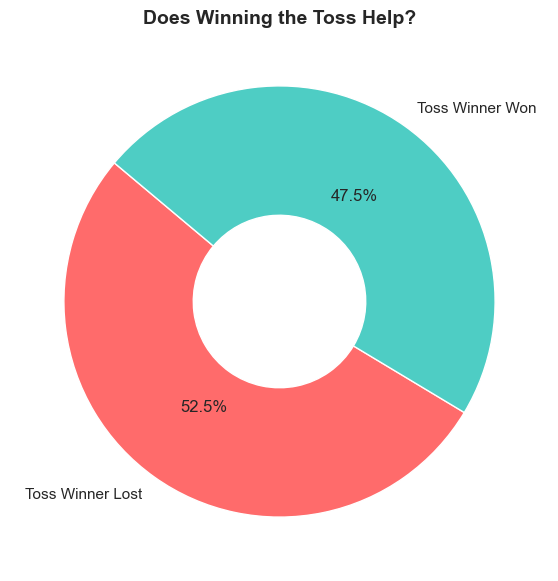

In [11]:
# --- Toss Impact ---
match_info['toss_won_match'] = match_info['toss_winner'] == match_info['winner']
toss_impact = match_info['toss_won_match'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(toss_impact.values,
        labels=['Toss Winner Lost', 'Toss Winner Won'],
        autopct='%1.1f%%',
        colors=['#ff6b6b', '#4ecdc4'],
        startangle=140,
        wedgeprops=dict(width=0.6))
plt.title('Does Winning the Toss Help?', fontsize=14, fontweight='bold')
plt.show()

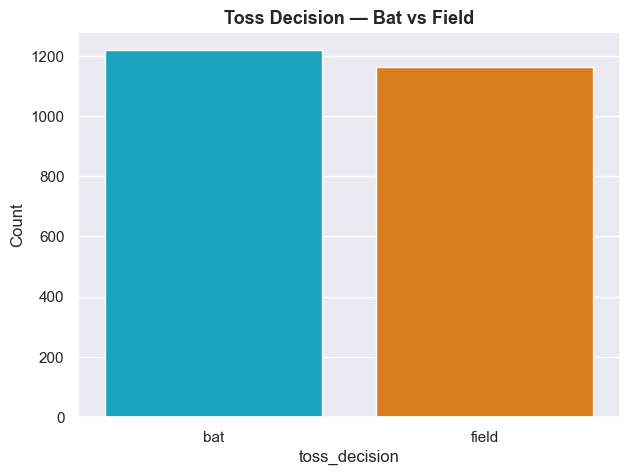

In [12]:
# --- Toss Decision: Bat vs Field ---
td = match_info['toss_decision'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=td.index, y=td.values, palette=['#00b4d8','#f77f00'])
plt.title('Toss Decision — Bat vs Field', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.show()

## Step 6 — Batting Analytics

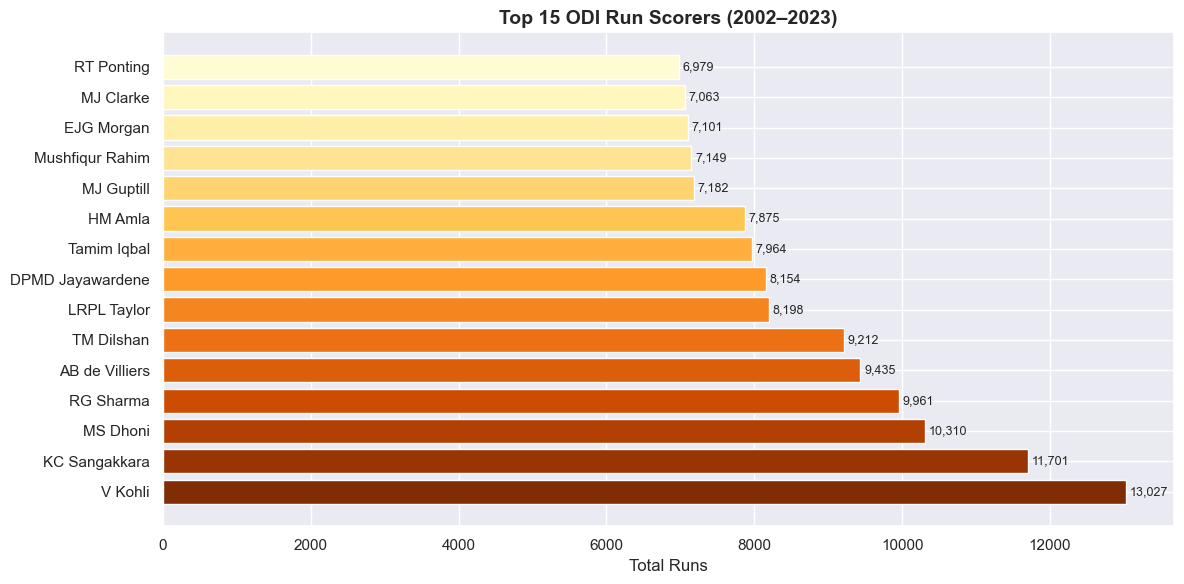

In [13]:
# --- Top Run Scorers ---
bat_stats = match_data.groupby('striker').agg(
    Runs   = ('runs_off_bat', 'sum'),
    Balls  = ('runs_off_bat', 'count'),
    Inns   = ('cricsheet_id', 'nunique')
).reset_index()
bat_stats['Strike_Rate'] = (bat_stats['Runs'] / bat_stats['Balls'] * 100).round(1)
bat_stats['Average']     = (bat_stats['Runs'] / bat_stats['Inns']).round(1)

top15 = bat_stats.nlargest(15, 'Runs')

plt.figure(figsize=(12,6))
bars = plt.barh(top15['striker'], top15['Runs'],
                color=sns.color_palette('YlOrBr_r', 15))
plt.xlabel('Total Runs')
plt.title('Top 15 ODI Run Scorers (2002–2023)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top15['Runs']):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

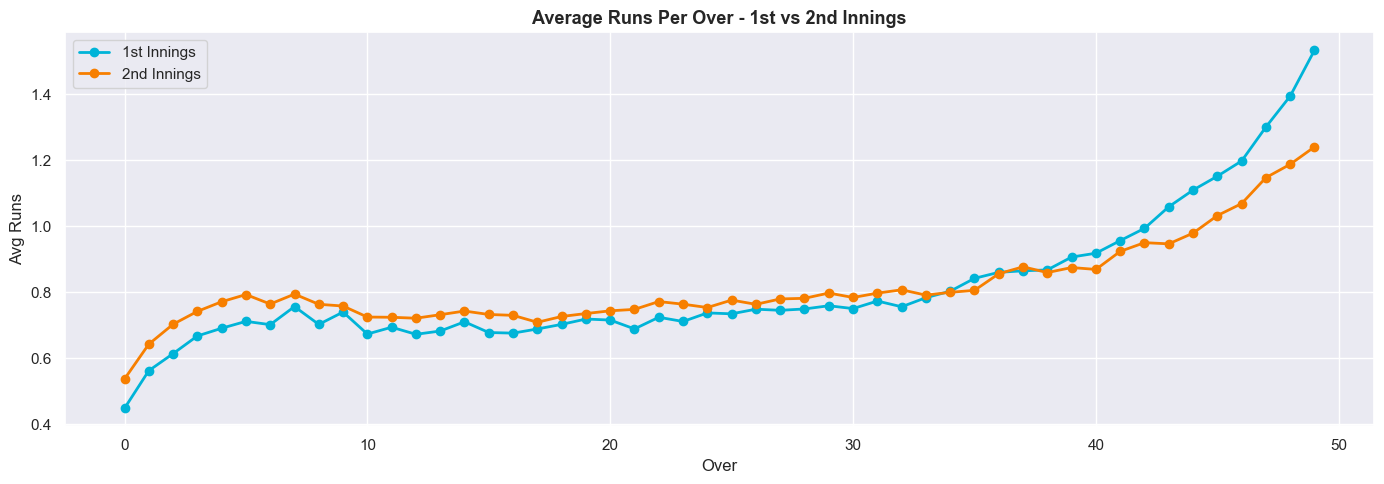

In [14]:
# --- Runs per Over (1st vs 2nd innings) ---
match_data['over_num'] = match_data['ball'].astype(str).str.split('.').str[0].astype(int)

over_runs = match_data.groupby(['innings', 'over_num'])['runs_off_bat'].mean().reset_index()
over_runs.columns = ['Inning', 'Over', 'Avg_Runs']

plt.figure(figsize=(14,5))
for inn, color, label in [(1,'#00b4d8','1st Innings'), (2,'#f77f00','2nd Innings')]:
    d = over_runs[over_runs['Inning'] == inn]
    if len(d) > 0:
        plt.plot(d['Over'], d['Avg_Runs'], marker='o', color=color, label=label, linewidth=2)

plt.xlabel('Over')
plt.ylabel('Avg Runs')
plt.title('Average Runs Per Over - 1st vs 2nd Innings', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7 — Bowling Analytics

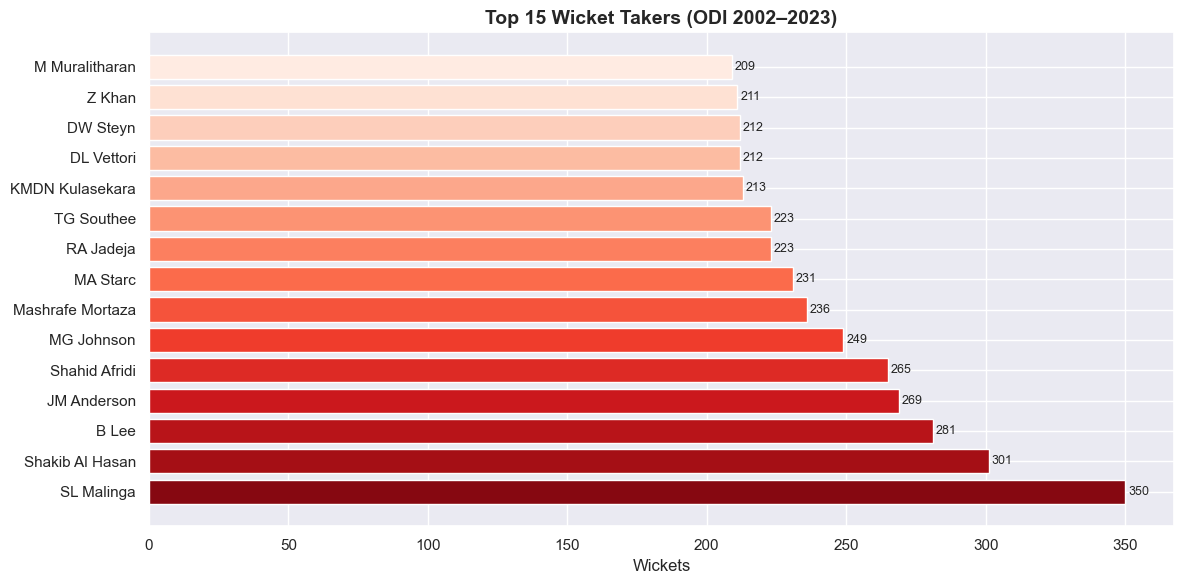

In [15]:
# --- Top Wicket Takers ---
bowl_stats = match_data.groupby('bowler').agg(
    Wickets    = ('wicket_type', lambda x: x.notna().sum()),
    Runs_Given = ('runs_off_bat', 'sum'),
    Balls      = ('runs_off_bat', 'count')
).reset_index()
bowl_stats['Economy'] = (bowl_stats['Runs_Given'] / (bowl_stats['Balls']/6)).round(2)
bowl_stats = bowl_stats[bowl_stats['Wickets'] > 5]
top15_bowl = bowl_stats.nlargest(15, 'Wickets')

plt.figure(figsize=(12,6))
bars = plt.barh(top15_bowl['bowler'], top15_bowl['Wickets'],
                color=sns.color_palette('Reds_r', 15))
plt.xlabel('Wickets')
plt.title('Top 15 Wicket Takers (ODI 2002–2023)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top15_bowl['Wickets']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=9)
plt.tight_layout()
plt.show()

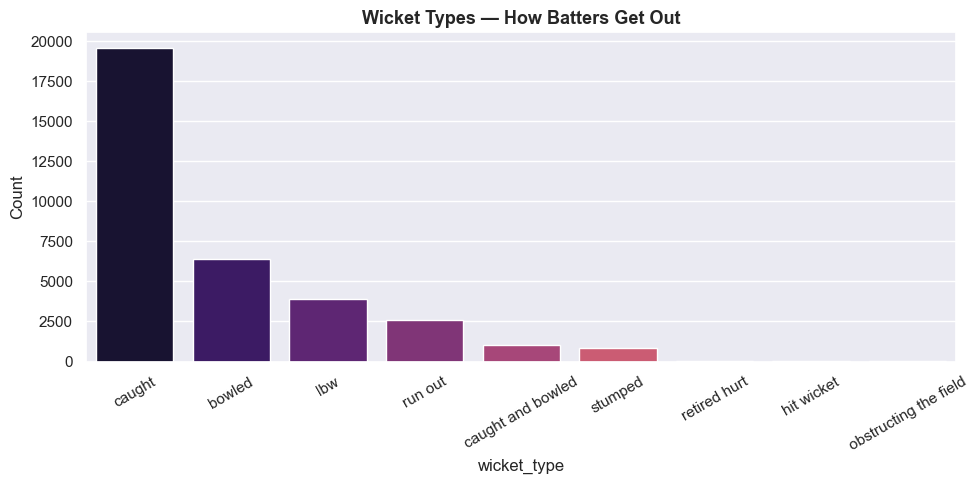

In [16]:
# --- Dismissal Types ---
dismissals = match_data['wicket_type'].value_counts().dropna()

plt.figure(figsize=(10,5))
sns.barplot(x=dismissals.index, y=dismissals.values,
            palette='magma')
plt.title('Wicket Types — How Batters Get Out', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 8 — Trend Analysis

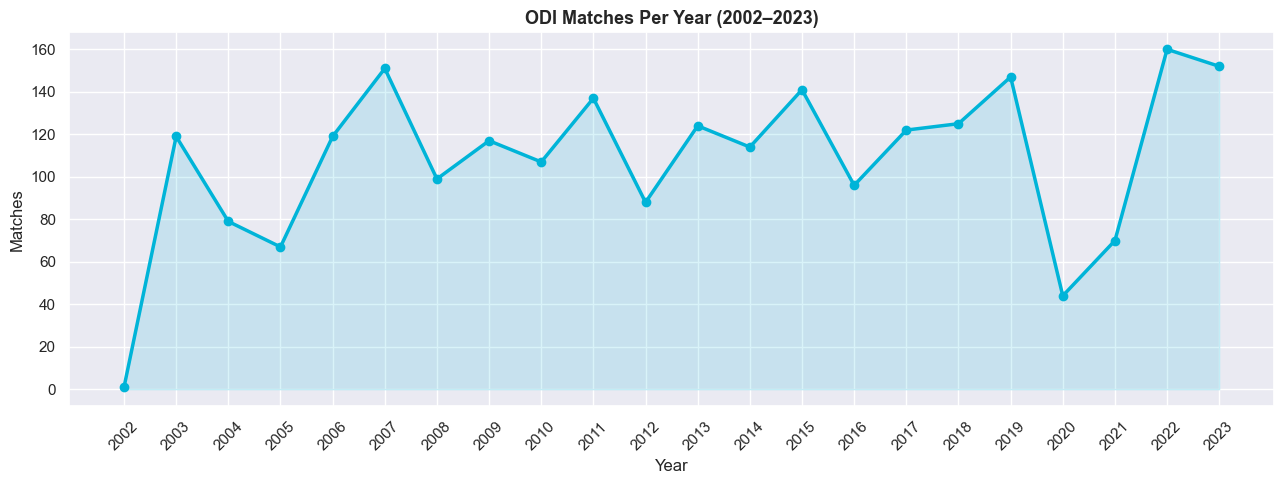

In [17]:
# --- Matches Per Year ---
matches_yr = match_info.groupby('year').size().reset_index(name='Matches')

plt.figure(figsize=(13,5))
plt.plot(matches_yr['year'], matches_yr['Matches'],
         marker='o', color='#00b4d8', linewidth=2.5)
plt.fill_between(matches_yr['year'], matches_yr['Matches'],
                 alpha=0.15, color='#00b4d8')
plt.xlabel('Year')
plt.ylabel('Matches')
plt.title('ODI Matches Per Year (2002–2023)', fontsize=13, fontweight='bold')
plt.xticks(matches_yr['year'], rotation=45)
plt.tight_layout()
plt.show()

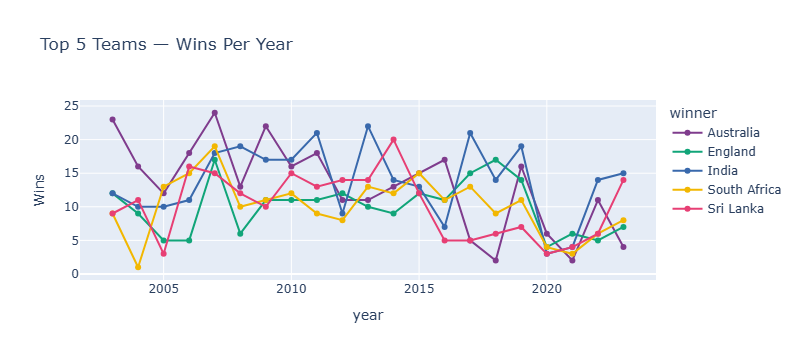

In [18]:
# --- Team Wins Per Year (Top 5 Teams) ---
top5_teams = match_info['winner'].value_counts().head(5).index.tolist()
wins_yr = match_info[match_info['winner'].isin(top5_teams)]
wins_yr = wins_yr.groupby(['year','winner']).size().reset_index(name='Wins')

fig = px.line(wins_yr, x='year', y='Wins', color='winner',
              markers=True, title='Top 5 Teams — Wins Per Year',
              color_discrete_sequence=px.colors.qualitative.Bold)
fig.show()

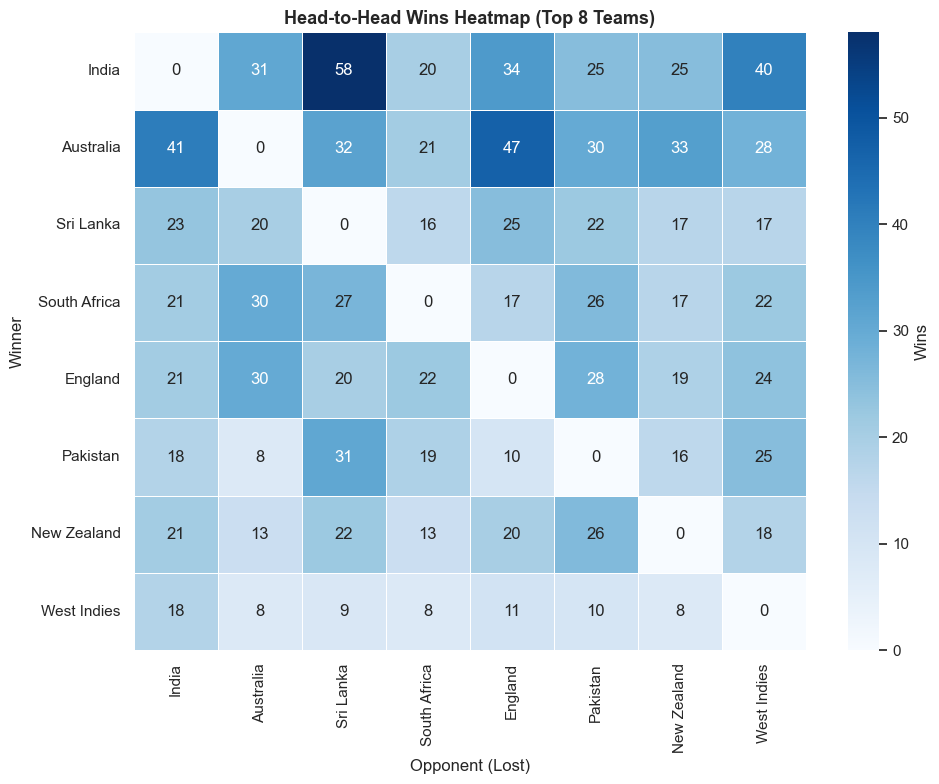

In [19]:
# --- Head-to-Head Heatmap ---
top8 = match_info['winner'].value_counts().head(8).index.tolist()
h2h  = pd.DataFrame(0, index=top8, columns=top8)

for _, row in match_info.iterrows():
    t1, t2, w = row.get('team1'), row.get('team2'), row.get('winner')
    if t1 in top8 and t2 in top8 and pd.notna(w) and w in top8:
        loser = t2 if w == t1 else t1
        if loser in top8:
            h2h.loc[w, loser] += 1

plt.figure(figsize=(10,8))
sns.heatmap(h2h, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Wins'})
plt.title('Head-to-Head Wins Heatmap (Top 8 Teams)', fontsize=13, fontweight='bold')
plt.ylabel('Winner')
plt.xlabel('Opponent (Lost)')
plt.tight_layout()
plt.show()

## Step 9 — Pakistan Performance

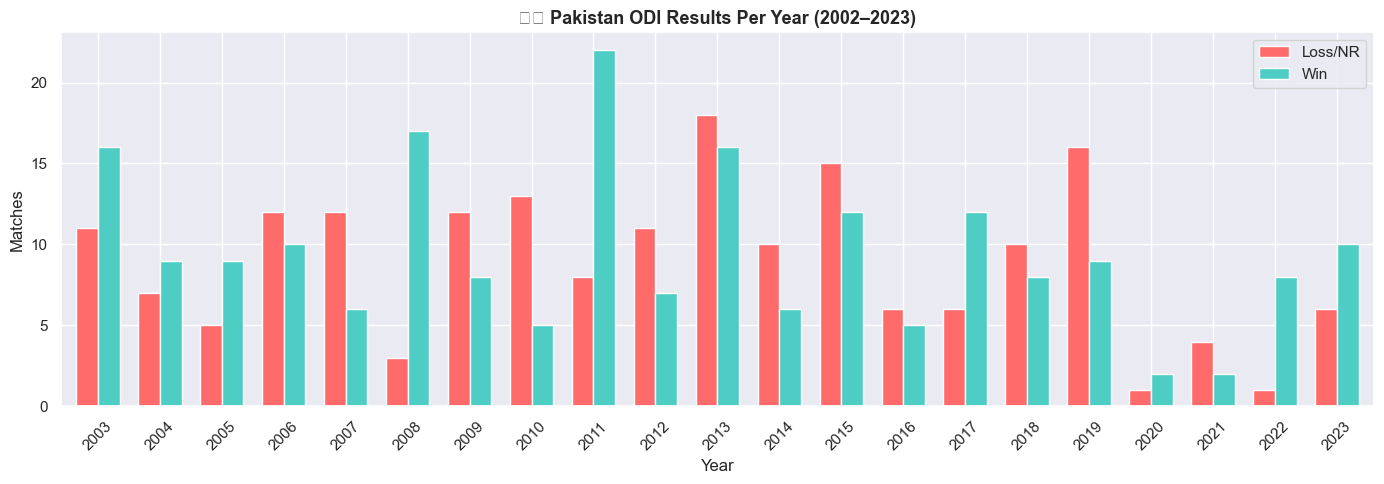

In [20]:
# --- Pakistan Wins vs Losses Per Year ---
pak = match_info[
    (match_info['team1'] == 'Pakistan') | (match_info['team2'] == 'Pakistan')
].copy()
pak['Result'] = pak['winner'].apply(lambda w: 'Win' if w == 'Pakistan' else 'Loss/NR')
pak_yr = pak.groupby(['year','Result']).size().unstack(fill_value=0)

pak_yr.plot(kind='bar', figsize=(14,5),
            color=['#ff6b6b','#4ecdc4'], width=0.7)
plt.title('🇵🇰 Pakistan ODI Results Per Year (2002–2023)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Matches')
plt.legend(['Loss/NR','Win'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

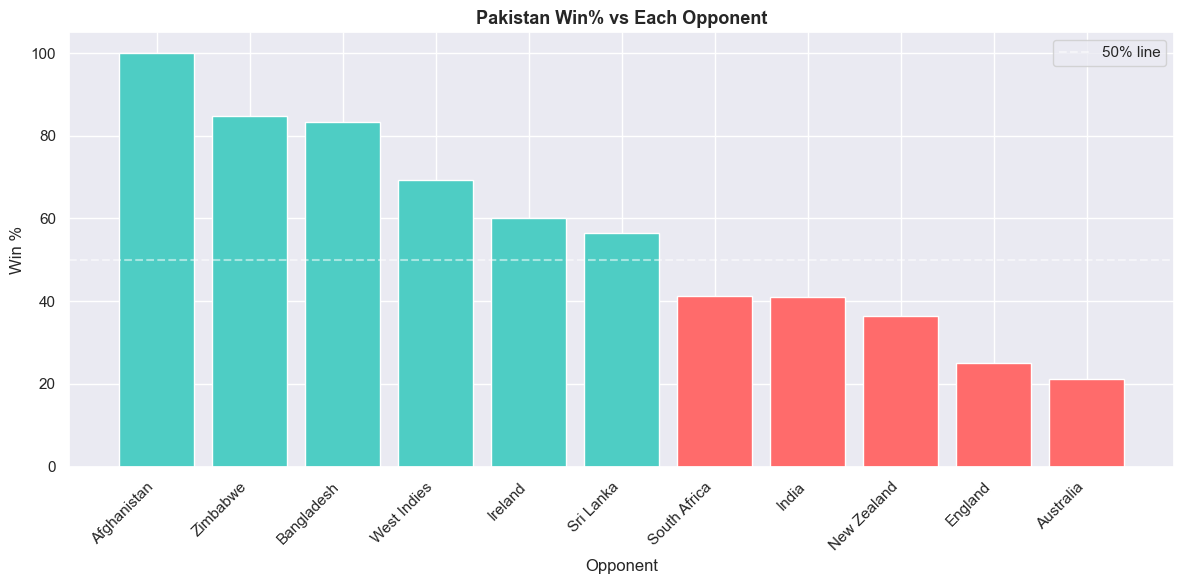

In [21]:
# --- Pakistan Win% vs Each Opponent ---
pak['Opponent'] = pak.apply(
    lambda r: r['team2'] if r['team1'] == 'Pakistan' else r['team1'], axis=1
)

opp_played = pak.groupby('Opponent').size().reset_index(name='Played')
opp_won = pak[pak['winner'] == 'Pakistan'].groupby('Opponent').size().reset_index(name='Won')

opp = opp_played.merge(opp_won, on='Opponent', how='left')
opp['Won'] = opp['Won'].fillna(0).astype(int)
opp['Win%'] = (opp['Won'] / opp['Played'] * 100).round(1)
opp = opp[opp['Played'] >= 5].sort_values('Win%', ascending=False)

plt.figure(figsize=(12,6))
colors = ['#4ecdc4' if w >= 50 else '#ff6b6b' for w in opp['Win%']]
plt.bar(opp['Opponent'], opp['Win%'], color=colors)
plt.axhline(50, color='white', linestyle='--', alpha=0.5, label='50% line')
plt.xlabel('Opponent')
plt.ylabel('Win %')
plt.title('Pakistan Win% vs Each Opponent', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# --- Summary Stats ---
print('='*40)
print('  🇵🇰 PAKISTAN ODI SUMMARY (2002–2023)')
print('='*40)
print(f"  Total Matches : {len(pak)}")
print(f"  Wins          : {(pak['Result']=='Win').sum()}")
print(f"  Losses/NR     : {(pak['Result']!='Win').sum()}")
win_pct = round((pak['Result']=='Win').mean()*100, 1)
print(f"  Win Rate      : {win_pct}%")
print('='*40)

  🇵🇰 PAKISTAN ODI SUMMARY (2002–2023)
  Total Matches : 386
  Wins          : 199
  Losses/NR     : 187
  Win Rate      : 51.6%


---
## EDA Complete!